In [21]:
# =========================================================
# FIGURES AND TABLES
# =========================================================

import os
import sys
import pandas as pd
sys.path.append("../src")

from figure_utils import (
    plot_actual_vs_forecasts,
    plot_monthly_rmse,
    plot_monthly_forecast_panels,
    plot_monthly_rmse_heatmap,
    plot_volatility_scenarios,
    plot_shap_country_comparison,
    plot_sarimax_variable_effect_distributions
)

from evaluation_utils import run_volatility_analysis

df = pd.read_csv("../data/processed_data.csv", index_col=0, parse_dates=True)

country = "Norway"
forecast_year = 2025

comparison_plot_df = pd.read_csv(
    f"../outputs/tables/{country}_comparison_plot_df_{forecast_year}.csv",
    index_col=0,
    parse_dates=True
)

monthly_table = pd.read_csv(
    f"../outputs/tables/{country}_monthly_metrics_{forecast_year}.csv"
)


In [ ]:
import figure_utils
print(dir(figure_utils))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'ensure_output_dir', 'np', 'os', 'pd', 'plot_acf_pacf_by_country', 'plot_actual_vs_forecasts', 'plot_extreme_boxplots', 'plot_hdd_cdd_relationships', 'plot_load_distributions', 'plot_monthly_forecast_panels', 'plot_monthly_rmse', 'plot_monthly_rmse_heatmap', 'plot_sarimax_variable_effect_distributions', 'plot_shap_country_comparison', 'plot_temp_vs_load', 'plot_volatility_scenarios', 'plt']


Saved: ../outputs/figures\Norway_actual_vs_forecast_2025.png


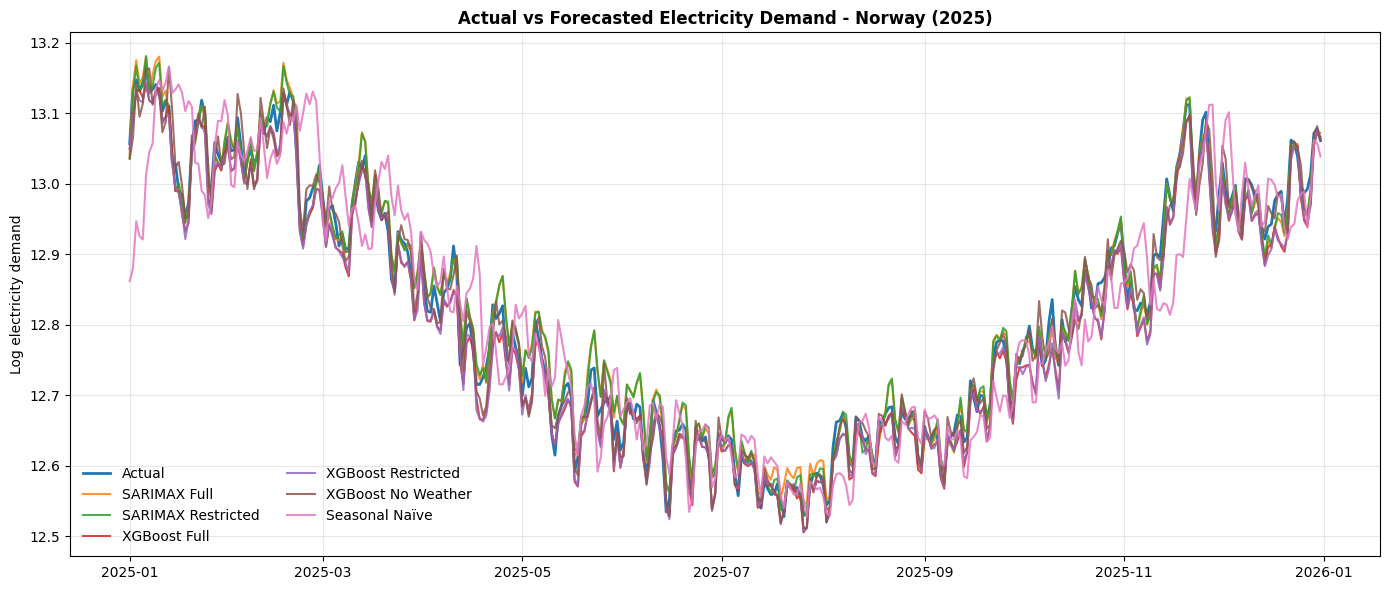

In [11]:
plot_actual_vs_forecasts(
    comparison_plot_df=comparison_plot_df,
    country=country,
    forecast_year=forecast_year,
    output_dir="../outputs/figures",
    save=True
)

Saved: outputs/figures\Norway_monthly_rmse_2025.png


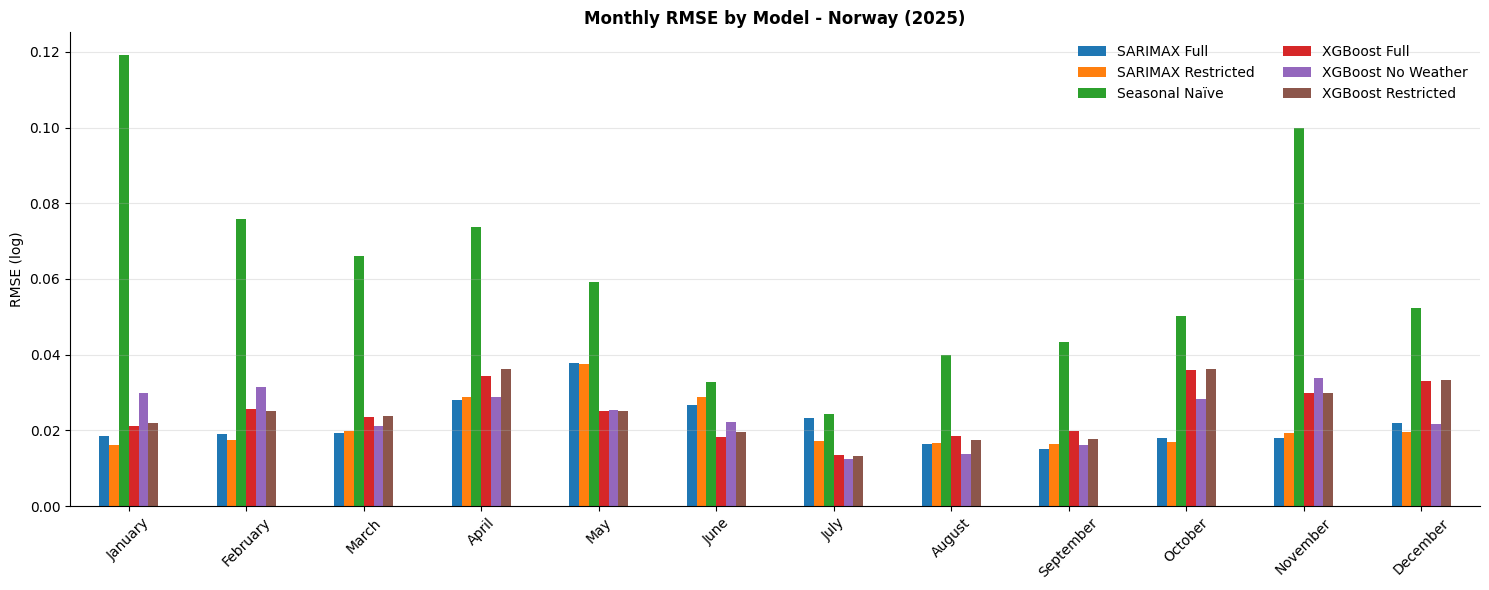

In [12]:
plot_monthly_rmse(
    monthly_table=monthly_table,
    country=country,
    forecast_year=forecast_year,
    output_dir="outputs/figures",
    save=True
)

In [22]:
summary_counts_all_df, performance_by_type_all_df, winners_all_df, plot_ready_tables = run_volatility_analysis(
    comparison_plot_df=comparison_plot_df,
    df=df,
    country=country,
    forecast_year=forecast_year,
    volatility_percentile_list=[90, 80, 75],
    temp_percentile_list=[90, 80, 75],
    pair_scenarios=True
)

Saved: ../outputs/figures\Norway_volatility_scenarios_2025.png


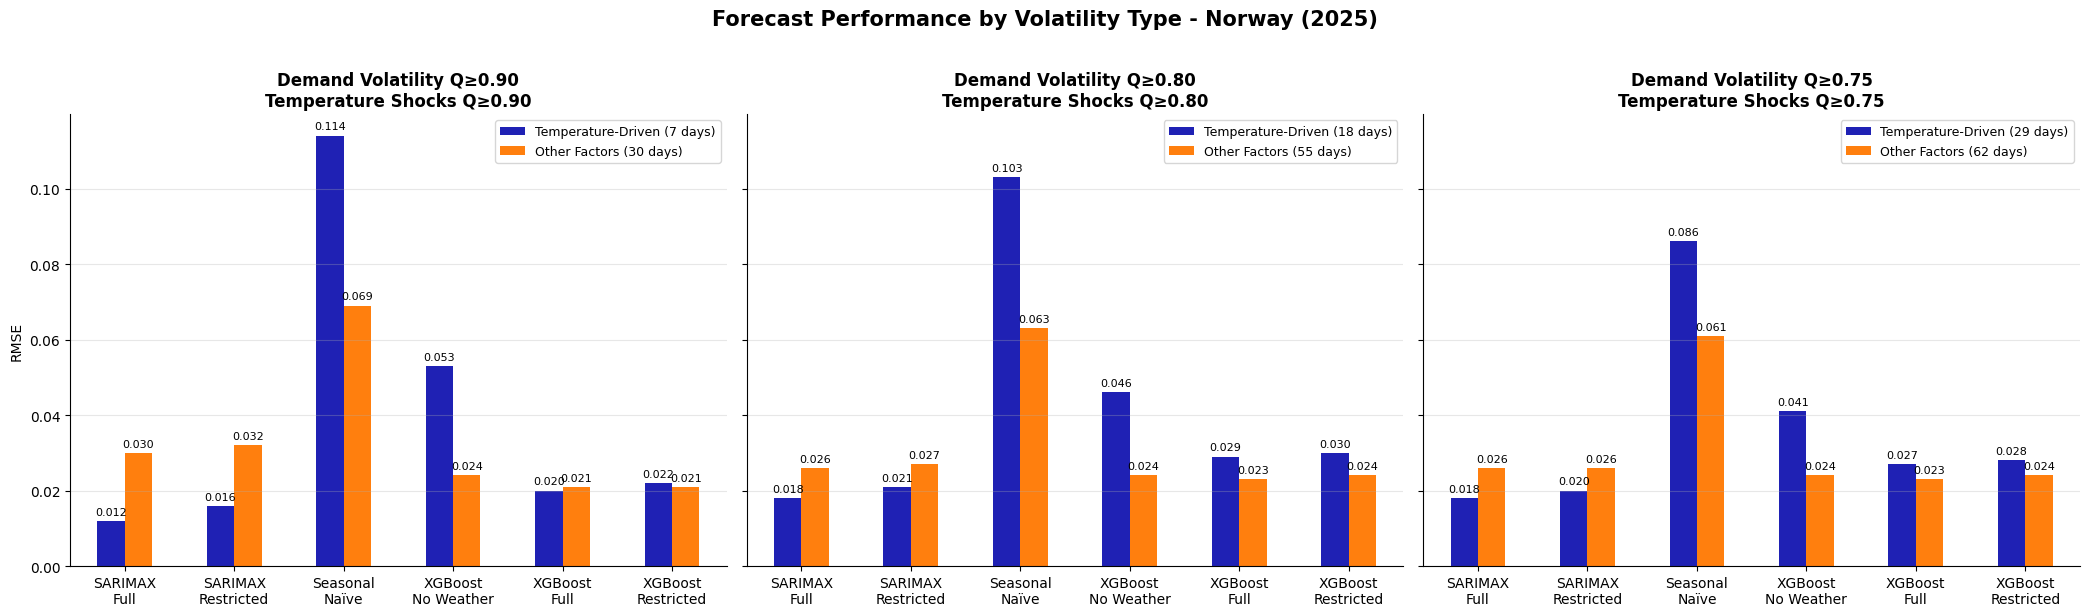

In [23]:
plot_volatility_scenarios(
    plot_ready_tables=plot_ready_tables,
    country=country,
    forecast_year=forecast_year,
    output_dir="../outputs/figures",
    save=True
)

Saved: ../outputs/figures\shap_country_comparison_2025.png


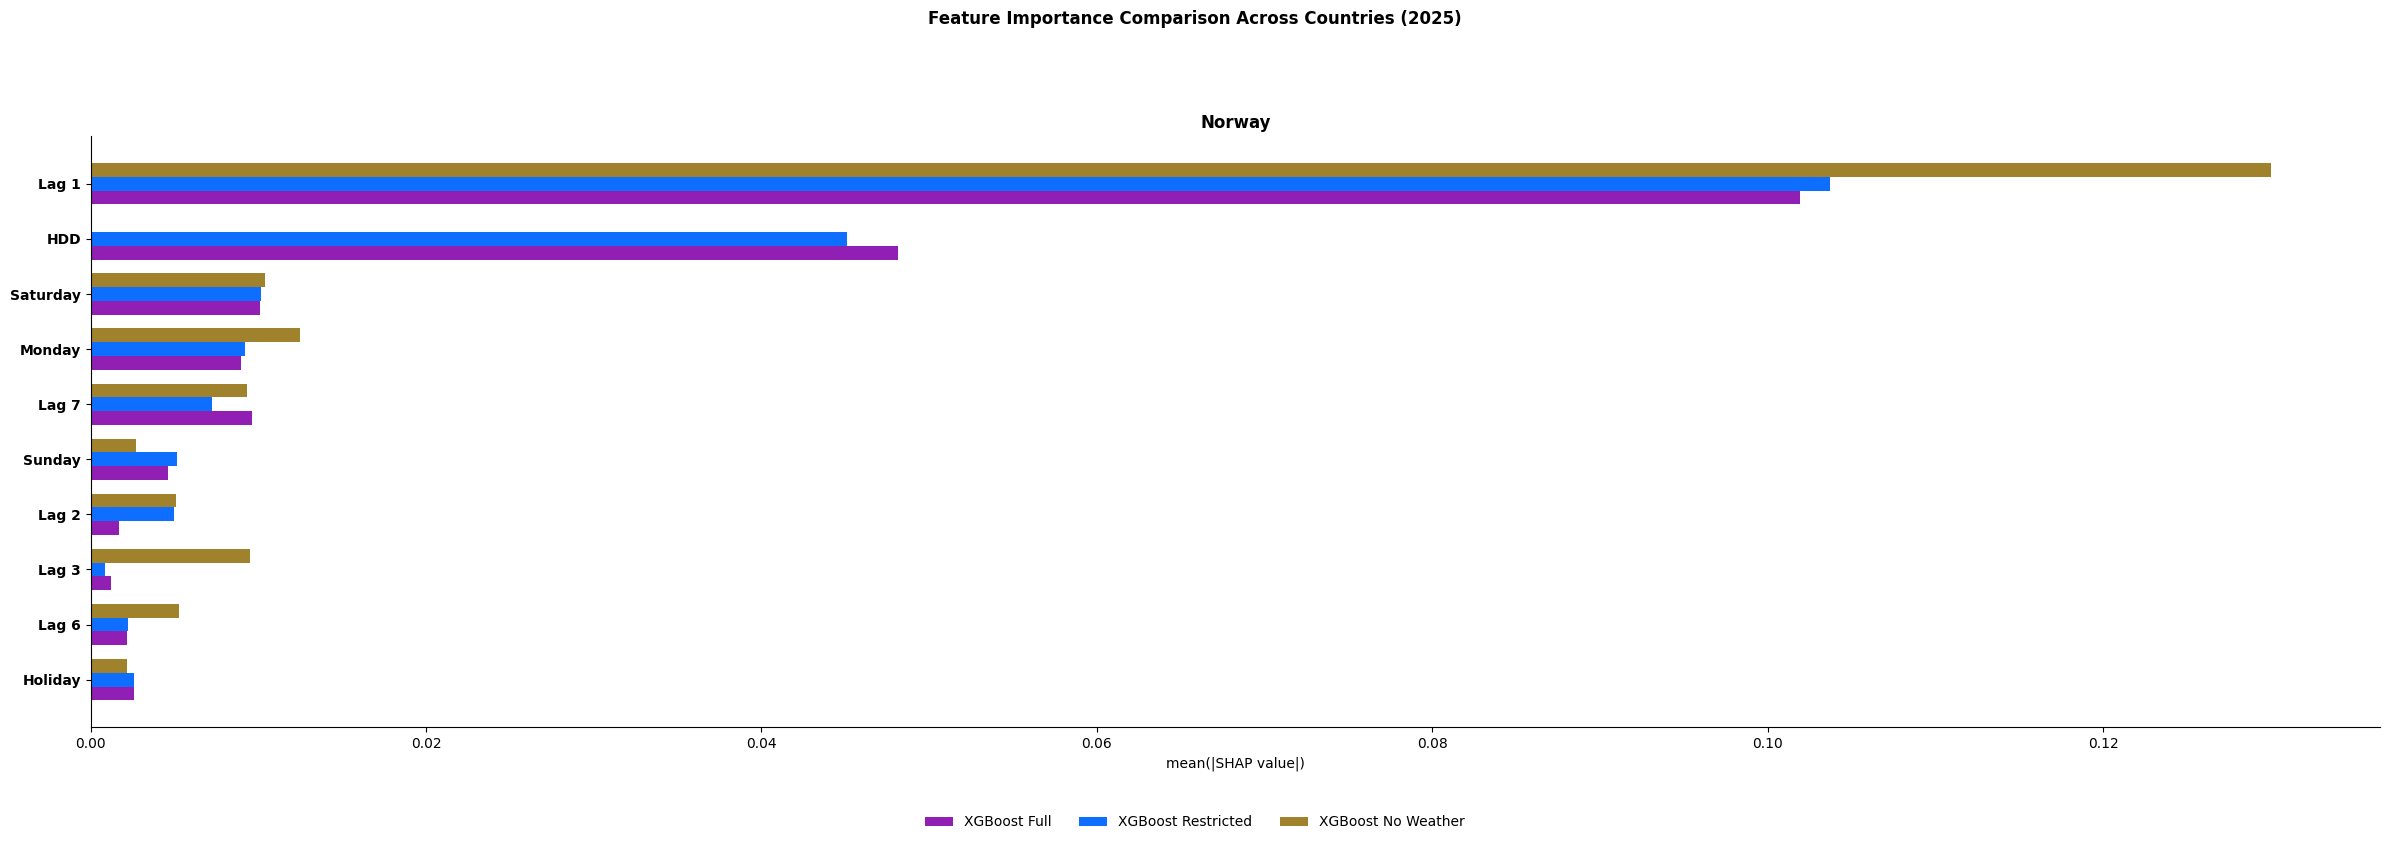

In [ ]:
plot_shap_country_comparison(
    input_dir="../outputs/tables",  
    forecast_year=forecast_year,
    countries=["Norway"],           
    top_n=10,
    output_dir="../outputs/figures",
    save=True
)

Saved: ../outputs/figures\sarimax_variable_effect_distributions.png


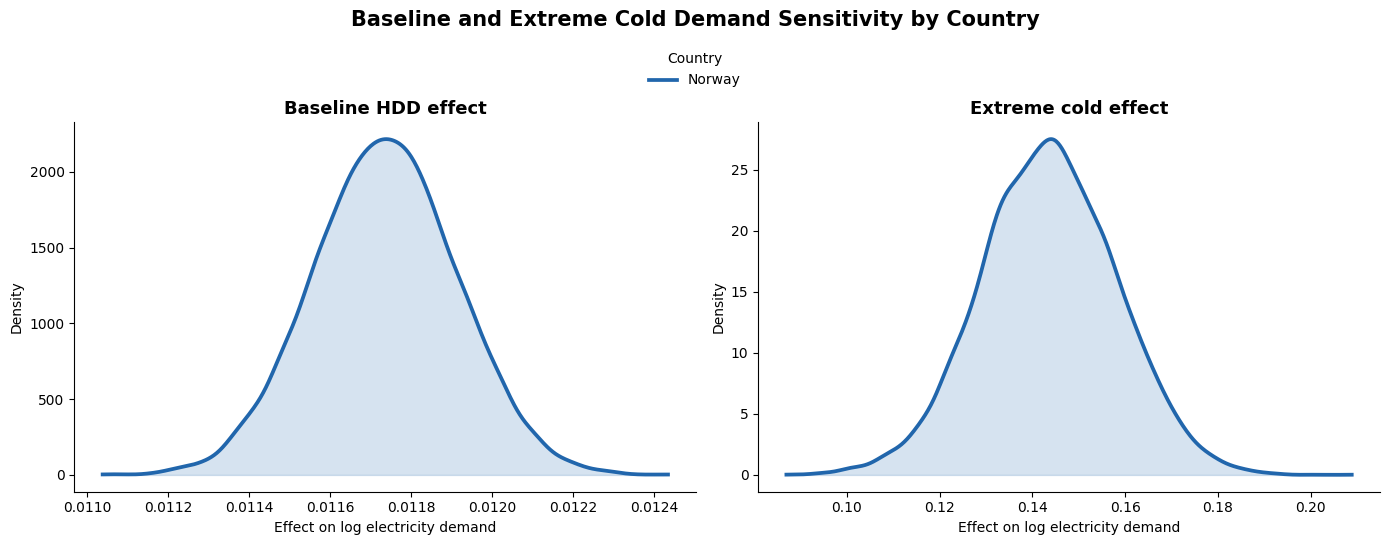

,Country,Effect,Simulated effect
0,Norway,Baseline HDD effect,0.011824
1,Norway,Baseline HDD effect,0.011711
2,Norway,Baseline HDD effect,0.011851
3,Norway,Baseline HDD effect,0.012007
4,Norway,Baseline HDD effect,0.011694


In [29]:
base_path = os.getcwd()

files = {
    "Norway": "../outputs/tables/Norway_restricted_sensitivity_results_2025.csv",
    # "Sweden": "../outputs/tables/Sweden_restricted_sensitivity_results_2025.csv",
    # "Finland": "../outputs/tables/Finland_restricted_sensitivity_results_2025.csv"
}
sim_df = plot_sarimax_variable_effect_distributions(
    files=files,
    n_sim=10000,
    seed=42,
    output_dir="../outputs/figures",
    save=True
)

sim_df.head()

Saved: outputs/figures\Norway_monthly_forecast_panels_winter_peak_log_2025.png


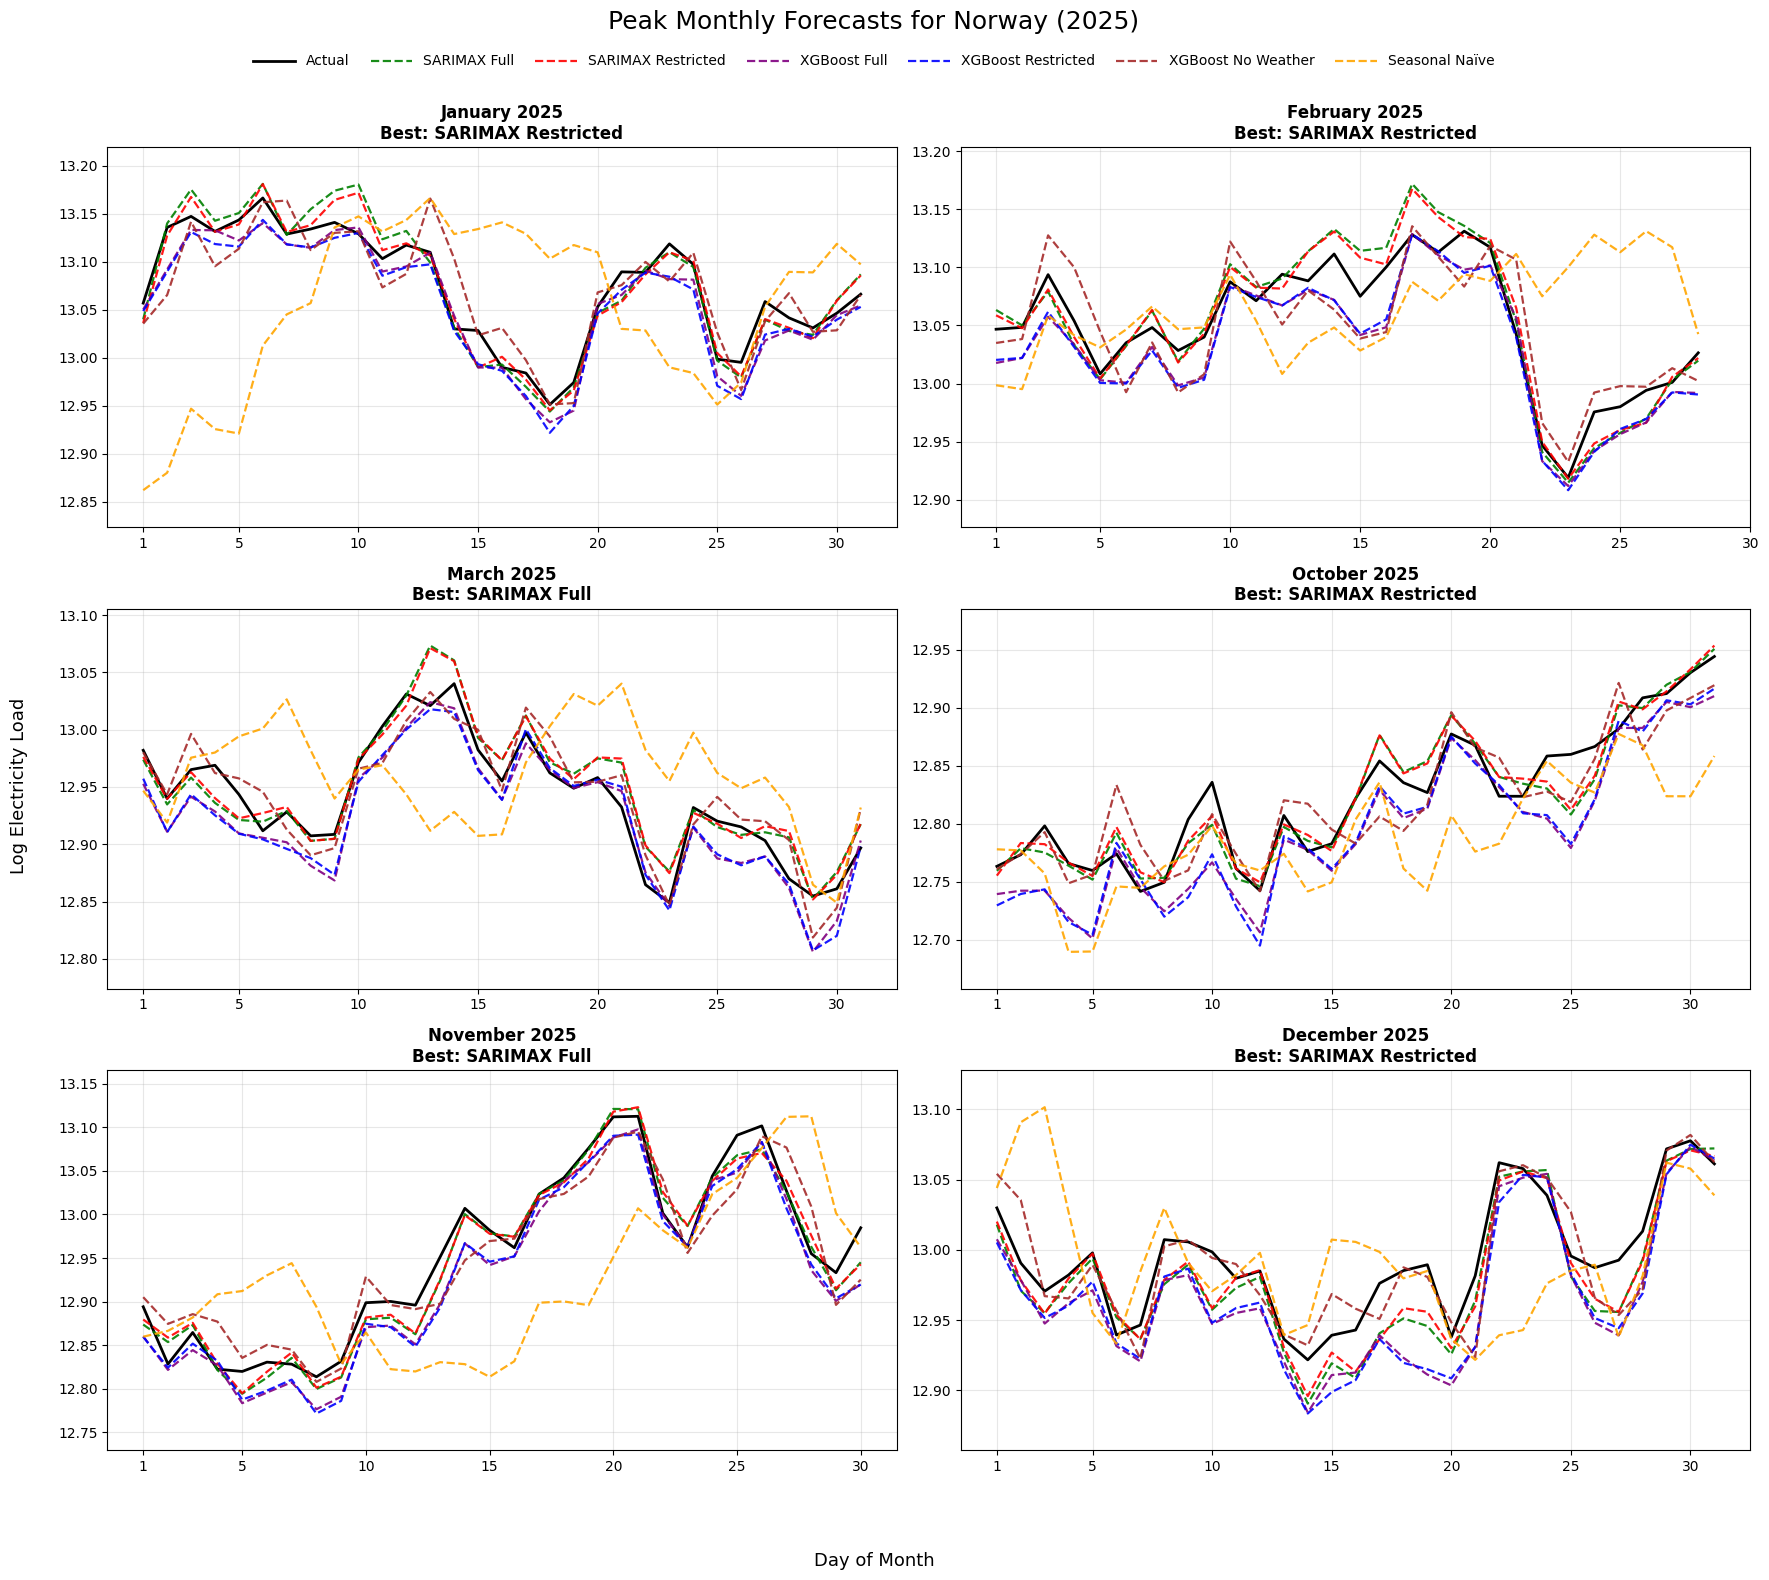

In [16]:
# Monthly forecast panels
# This function creates a grid of monthly forecast panels for a specified country and forecast year. 
# Each panel compares the actual electricity load against various forecast models for a given month.
plot_monthly_forecast_panels(
    comparison_plot_df=comparison_plot_df,
    country=country,
    forecast_year=forecast_year,
    plot_scale="log",
    duration="winter_peak",
    output_dir="outputs/figures",
    save=True
)

Saved: outputs/figures\Norway_monthly_rmse_heatmap_2025.png


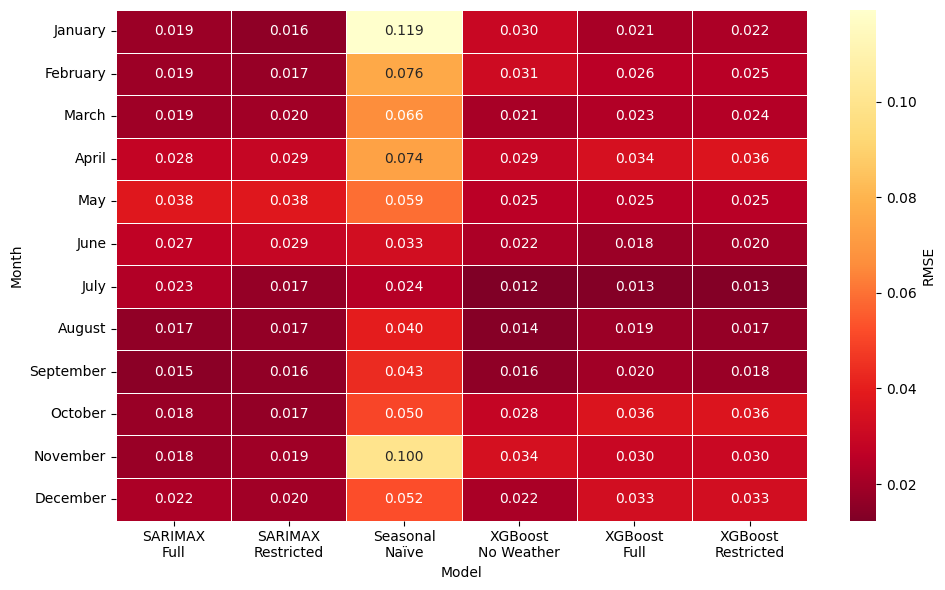

In [17]:
# Monthly RMSE heatmap
# This function generates a heatmap of monthly RMSE values for different forecast models across the months of a specified forecast year.
plot_monthly_rmse_heatmap(
    monthly_table=monthly_table,
    country=country,
    forecast_year=forecast_year,
    output_dir="outputs/figures",
    save=True
)